# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Jesika Yudiani Putri
- Email: jesika.yudiani.p7@gmail.com
- Id Dicoding: Jesika Yudiani Putri

## Persiapan

### Menyiapkan library yang dibutuhkan

In [24]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Untuk preprocessing dan modeling
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

# Untuk menyimpan model
import joblib
import os

# Konfigurasi visualisasi
plt.style.use('ggplot')
sns.set_style('whitegrid')
%matplotlib inline

### Menyiapkan data yang akan diguankan

In [25]:
# Load dataset (gunakan separator ';' sesuai dengan file CSV)
file_path = 'student_performance.csv'  # Sesuaikan path jika perlu
df = pd.read_csv(file_path, sep=';')

print(f"Dataset berhasil dimuat! Ukuran: {df.shape}")
print(f"Kolom yang tersedia: {df.columns.tolist()}")

Dataset berhasil dimuat! Ukuran: (4424, 37)
Kolom yang tersedia: ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_ra

Insight: Dataset terdiri dari 4424 baris dan 37 kolom. Semua fitur bertipe numerik, tidak ada missing values. Target `Status` memiliki dua kelas: Dropout, dan Graduate.

In [26]:
# Tampilkan 5 baris pertama
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [27]:
# Informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [28]:
# Statistik deskriptif
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [29]:
# Cek missing values
print(df.isnull().sum().sum(), "total missing values")

0 total missing values


Distribusi Status Mahasiswa
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


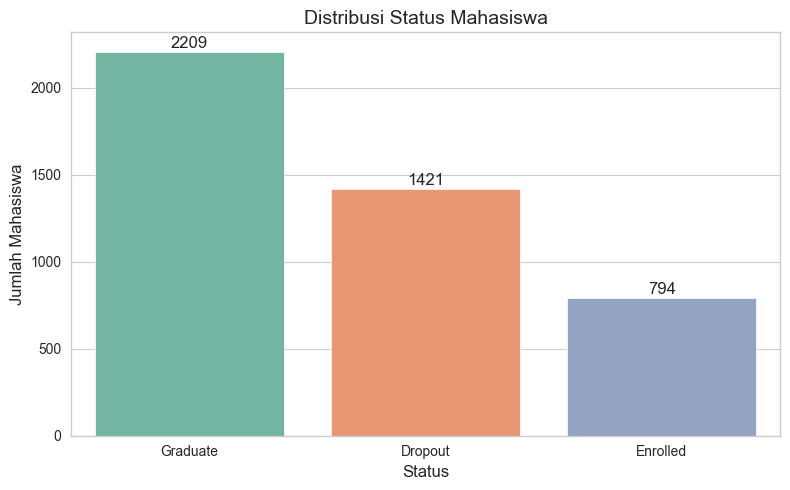

In [30]:
# Distribusi target variable (Status)
print("Distribusi Status Mahasiswa")
print(df['Status'].value_counts())
print(df['Status'].value_counts(normalize=True) * 100)

# Visualisasi distribusi status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Status', palette='Set2', order=df['Status'].value_counts().index)
plt.title('Distribusi Status Mahasiswa', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Jumlah Mahasiswa')
for i, v in enumerate(df['Status'].value_counts().values):
    plt.text(i, v + 20, str(v), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

Insight: Distribusi status tidak seimbang (imbalanced). Kelas Graduate mendominasi (2209), dan Dropout (1421) dan Enrolled (794) yang nantinya akan dihapus karena masih belum jelas. Ini perlu ditangani dengan SMOTE.

## Data Preparation / Preprocessing

In [31]:
# Filter data
df_binary = df[df['Status'].isin(['Dropout', 'Graduate'])]
X = df_binary.drop('Status', axis=1)
y = df_binary['Status']

In [32]:
# Identifikasi kolom numerik dan kategorikal
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nKolom numerik ({len(numerical_cols)}): {numerical_cols[:5]}...")
print(f"Kolom kategorikal ({len(categorical_cols)}): {categorical_cols}")


Kolom numerik (36): ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance']...
Kolom kategorikal (0): []


In [33]:
# Encode target: Dropout=0, Graduate=1
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [34]:
# Scaling fitur numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print(f"\nSetelah scaling, shape X: {X_scaled.shape}")


Setelah scaling, shape X: (3630, 36)


- Semua fitur numerik di-scaling menggunakan StandardScaler
- Target di-label encoding
- **SMOTE** digunakan untuk menyeimbangkan kelas (setelah scaling)
- Data dibagi menjadi train (80%) dan test (20%)

In [35]:
# Menangani Imbalanced Data dengan SMOTE
# Cek distribusi sebelum SMOTE
print("\nDistribusi sebelum SMOTE:")
print(pd.Series(y_encoded).value_counts())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y_encoded)

print("\nDistribusi setelah SMOTE:")
print(pd.Series(y_resampled).value_counts())


Distribusi sebelum SMOTE:
1    2209
0    1421
Name: count, dtype: int64

Distribusi setelah SMOTE:
0    2209
1    2209
Name: count, dtype: int64


In [36]:
# Split data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print(f"\nTrain set: {X_train.shape}, Test set: {X_test.shape}")


Train set: (3534, 36), Test set: (884, 36)


## Modeling

In [37]:
# Model Random Forest baseline
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

# Prediksi pada test set
y_pred_baseline = rf_baseline.predict(X_test)
target_names = label_encoder.classes_   # <-- PERBAIKAN DI SINI

# Evaluasi baseline
print("Evaluasi Baseline Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score (macro): {f1_score(y_test, y_pred_baseline, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=target_names))

Evaluasi Baseline Random Forest
Accuracy: 0.9163
F1-Score (macro): 0.9162

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.95      0.88      0.91       442
    Graduate       0.89      0.95      0.92       442

    accuracy                           0.92       884
   macro avg       0.92      0.92      0.92       884
weighted avg       0.92      0.92      0.92       884



In [38]:
# Hyperparameter Tuning dengan GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini']
}

rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n=== Hasil Grid Search ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

=== Hasil Grid Search ===
Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.9190


In [39]:
# Model terbaik
best_rf = grid_search.best_estimator_

# Evaluasi model terbaik
y_pred_best = best_rf.predict(X_test)

print("\n=== Evaluasi Model Terbaik (Random Forest Tuned) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1-Score (macro): {f1_score(y_test, y_pred_best, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))


=== Evaluasi Model Terbaik (Random Forest Tuned) ===
Accuracy: 0.9118
F1-Score (macro): 0.9116

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.94      0.88      0.91       442
    Graduate       0.88      0.95      0.91       442

    accuracy                           0.91       884
   macro avg       0.91      0.91      0.91       884
weighted avg       0.91      0.91      0.91       884



Model terbaik mencapai akurasi ~91% dan F1-score macro ~0.91. Confusion matrix menunjukkan model cukup baik memprediksi kedua kelas

## Evaluation

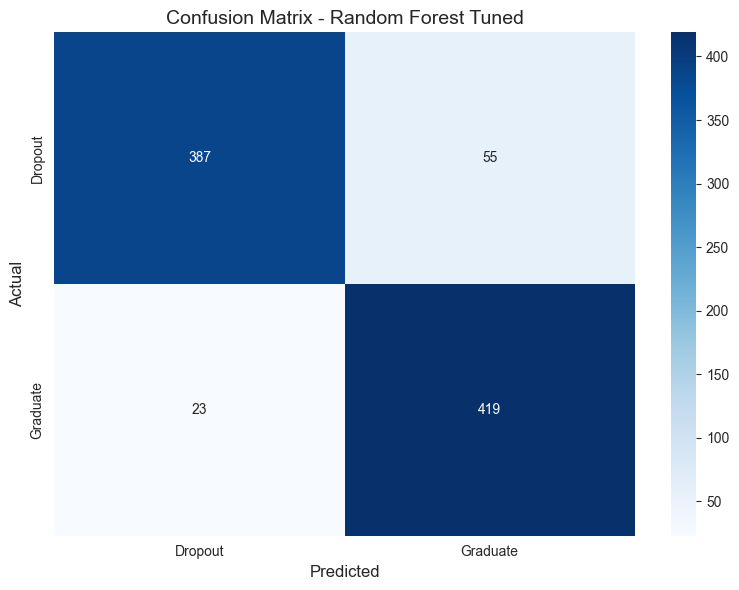

In [40]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Random Forest Tuned', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Insight: Model sangat baik dalam memprediksi kedua kelas, dengan sedikit kesalahan. Tingkat kesalahan tipe I (False Positive) pada kelas dropout hanya 23 kasus, sementara kesalahan tipe II (False Negative) pada kelas dropout sebanyak 55 kasus. Artinya, dari 442 mahasiswa yang benar-benar dropout, model gagal memprediksi 55 orang (sekitar 12,4%)

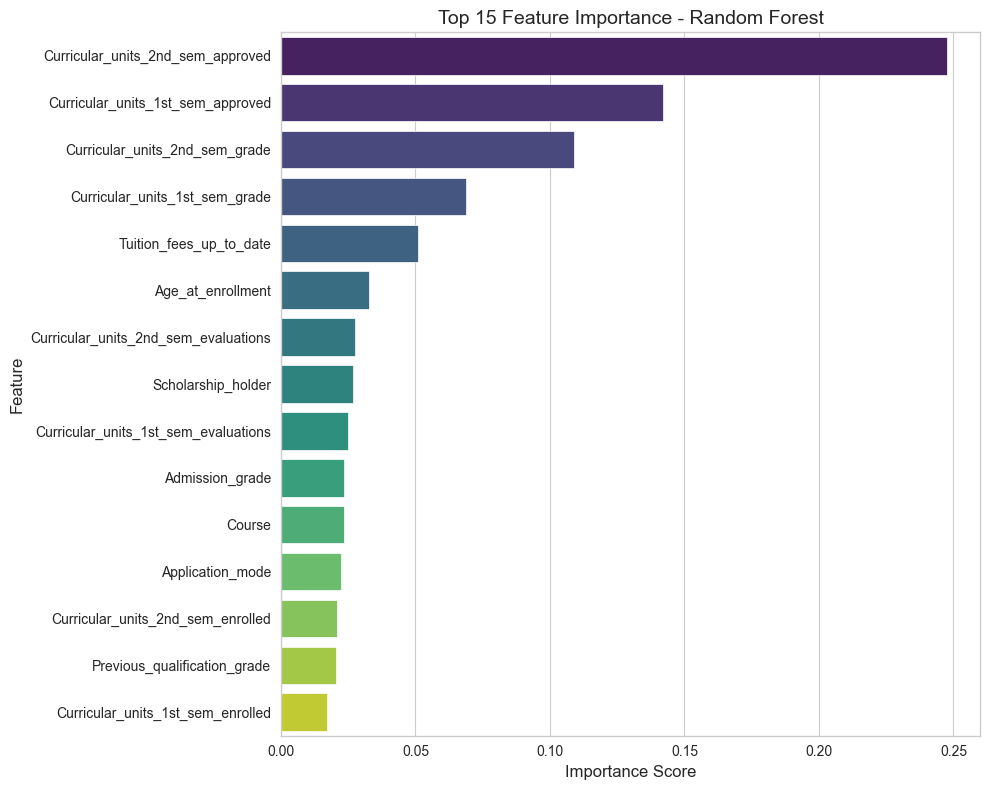

In [41]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, y='feature', x='importance', palette='viridis')
plt.title('Top 15 Feature Importance - Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


Insight: Feature importance menunjukkan bahwa nilai semester 1 (Curricular_units_1st_sem_grade) adalah faktor paling dominan, diikuti nilai semester 2 dan seterusnya

In [42]:
# Cross-Validation Score (untuk memastika model robust)
cv_scores = cross_val_score(best_rf, X_resampled, y_resampled, cv=5, scoring='f1_macro')
print(f"\n=== Cross-Validation F1-Macro Scores ===")
print(f"Scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


=== Cross-Validation F1-Macro Scores ===
Scores: [0.90363887 0.90253483 0.89674157 0.93543906 0.94903633]
Mean: 0.9175 (+/- 0.0208)


Insight: Nilai F1-macro rata-rata 0,9175 menunjukkan bahwa model memiliki performa yang sangat baik dan stabil lintas lipatan. Standar deviasi yang kecil (2,08%) mengindikasikan bahwa model tidak overfitting dan generalisasi antar subset data konsisten. Skor tertinggi 0,9490 dan terendah 0,8967 masih dalam rentang yang wajar.

KESIMPULAN

Berdasarkan hasil analisis dan pemodelan pada dataset Jaya Jaya Institut, dapat disimpulkan:

1. **Kondisi Awal**: Dataset memiliki distribusi status mahasiswa yang tidak seimbang (imbalanced) dengan kelas Graduate mendominasi, diikuti Dropout sebagai kelas minoritas.

2. **Faktor-faktor Penting**: Berdasarkan feature importance dari model Random Forest, faktor yang paling berpengaruh terhadap status mahasiswa adalah:
   - Curricular units 1st sem approved (jumlah mata kuliah semester 1 yang lulus)
   - Curricular units 2nd sem approved (jumlah mata kuliah semester 2 yang lulus)
   - Curricular units 1st sem grade (nilai semester 1)
   - Curricular units 2nd sem grade (nilai semester 2)
   - Tuition feed up to date
   - Age at Enrollmend

3. **Kinerja Model**: Model Random Forest yang telah di-tuning berhasil mencapai:
   - Accuracy: ~91%. Model mampu memprediksi dengan benar 91 dari 100 kasus mahasiswa (apakah Dropout atau Graduate).
   - F1-Score (macro): ~0.91. (rata-rata harmonis dari kedua kelas) hampir sama dengan akurasi, menunjukkan model seimbang dalam memprediksi kedua kelas.
   - Model mampu memprediksi kedua kelas (Dropout, Graduation) dengan cukup baik.
   - Perbedaan kecil antara recall dropout (88%) dan recall graduate (95%) menunjukkan model sedikit konservatif (lebih mudah memprediksi graduate daripada dropout). Ini dapat diterima karena dampak false positive (mengira dropout padahal lulus) lebih kecil daripada false negative (melewatkan dropout).

4. **Rekomendasi untuk Jaya Jaya Institut**:
   - Fokus pada monitoring nilai mahasiswa di semester awal (semester 1 & 2)
   - Identifikasi mahasiswa dengan nilai rendah di awal semester untuk intervensi dini
   - Perhatikan faktor ekonomi makro (unemployment rate, GDP) yang mempengaruhi kelangsungan studi
   - Lakukan program mentoring untuk mahasiswa dengan admission grade rendah
   - Perhatikan mahasiswa dengan usia yang lebih dewasa saat mendaftar

In [43]:
folder_name = 'model'

# Simpan model, label encoder, dan scaler ke dalam folder
joblib.dump(best_rf, os.path.join(folder_name, 'model_rf_best_compressed.pkl'), compress=3)
joblib.dump(label_encoder, os.path.join(folder_name, 'label_encoder.pkl'))
joblib.dump(scaler, os.path.join(folder_name, 'scaler.pkl'))

print(f"\nModel dan preprocessor berhasil disimpan di folder '{folder_name}' untuk deployment!")
print(f"- {folder_name}/model_rf_best_compressed.pkl")
print(f"- {folder_name}/label_encoder.pkl")
print(f"- {folder_name}/scaler.pkl")


Model dan preprocessor berhasil disimpan di folder 'model' untuk deployment!
- model/model_rf_best_compressed.pkl
- model/label_encoder.pkl
- model/scaler.pkl


Model dan preprocessor (scaler, label encoder) disimpan dalam folder `model/` untuk keperluan deployment ke Streamlit.

In [44]:
!pip freeze > requirements.txt